In [ ]:
import random
import numpy as np
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Generador de laberinto

In [ ]:
# constantes
CAMINO = 0
PARED = 1
ORIGEN = 2
META = 3
VISITADO = 4
SOLUCION = 5

# Paleta de colores: [Blanco, Negro, Azul, Rojo, Celeste, Amarillo]
colores_laberinto = ListedColormap(['#FFFFFF', '#1A1A1A', '#007BFF', '#DC3545', '#AED6F1', '#F1C40F'])

# parametros
sys.setrecursionlimit(5000)
probabilidad_romper_pared=0.05
ANCHO = 200
ALTO = 200

In [ ]:
"""
    Genera una matriz bidimensional que representa un laberinto aleatorio
    utilizando búsqueda en profundidad (DFS) con backtracking.

    Args:
        ancho (int): El número de columnas (se ajustará a impar).
        alto (int): El número de filas (se ajustará a impar).
        probabilidad_romper (float): probabilidad [0 a 1] de romper una pared en cada casilla

    Returns:
        list[list[int]]: Matriz con valores CAMINO, PARED, ORIGEN y META.
"""
def generar_laberinto(ancho, alto, probabilidad_romper):
    if ancho % 2 == 0: ancho += 1
    if alto % 2 == 0: alto += 1

    # Inicializar lleno de Paredes
    laberinto = [[PARED for _ in range(ancho)] for _ in range(alto)]

    def excavar(x, y):
        laberinto[y][x] = CAMINO
        direcciones = [(0, -2), (2, 0), (0, 2), (-2, 0)]
        random.shuffle(direcciones)

        for dx, dy in direcciones:
            nx, ny = x + dx, y + dy
            if 1 <= nx < ancho - 1 and 1 <= ny < alto - 1 and laberinto[ny][nx] == PARED:
                laberinto[y + dy // 2][x + dx // 2] = CAMINO
                excavar(nx, ny)

    # 1. Generar laberinto base (Perfecto)
    inicio_x = random.randrange(1, ancho, 2)
    inicio_y = random.randrange(1, alto, 2)
    excavar(inicio_x, inicio_y)

    # 2. Romper paredes aleatoriamente para crear ciclos (Caminos múltiples)
    for y in range(1, alto - 1):
        for x in range(1, ancho - 1):
            if laberinto[y][x] == PARED:
                # Solo romper si la pared separa dos caminos (evita áreas abiertas feas)
                # Revisar si hay caminos a los lados (horizontal o vertical)
                es_pared_horizontal = (laberinto[y][x-1] == CAMINO and laberinto[y][x+1] == CAMINO)
                es_pared_vertical = (laberinto[y-1][x] == CAMINO and laberinto[y+1][x] == CAMINO)

                if (es_pared_horizontal or es_pared_vertical) and random.random() < probabilidad_romper:
                    laberinto[y][x] = CAMINO

    # 3. Establecer Puntos de Interés
    laberinto[1][0] = ORIGEN
    laberinto[alto - 2][ancho - 1] = META

    return laberinto


"""
    Usa Matplotlib para renderizar la matriz del laberinto con colores personalizados y leyenda.
"""
def dibujar_laberinto_grafico(laberinto, titulo="Laberinto"):
    fig, ax = plt.subplots(figsize=(12, 10))

    img = ax.imshow(laberinto, cmap=colores_laberinto, interpolation='nearest', vmin=0, vmax=5)

    ax.axis('off')
    plt.title(titulo, fontsize=18, fontweight='bold', pad=20)

    parches = [
        mpatches.Patch(color='#1A1A1A', label='Pared'),
        mpatches.Patch(color='#FFFFFF', label='Camino', ec='#CCCCCC'),
        mpatches.Patch(color='#007BFF', label='Origen'),
        mpatches.Patch(color='#DC3545', label='Meta'),
        mpatches.Patch(color='#AED6F1', label='Explorado'),
        mpatches.Patch(color='#F1C40F', label='Solución')
    ]

    ax.legend(handles=parches,
              loc='upper center',
              bbox_to_anchor=(0.5, -0.02),
              fancybox=True,
              shadow=True,
              ncol=3,
              fontsize=11)

    plt.tight_layout()
    plt.show()

"""
    Encuentra las coordenadas (f, c) de un valor específico.
"""
def obtener_posicion(laberinto, valor):

    for f, fila in enumerate(laberinto):
        for c, celda in enumerate(fila):
            if celda == valor:
                return (f, c)
    return None

Generando y dibujando laberinto de 200x200...


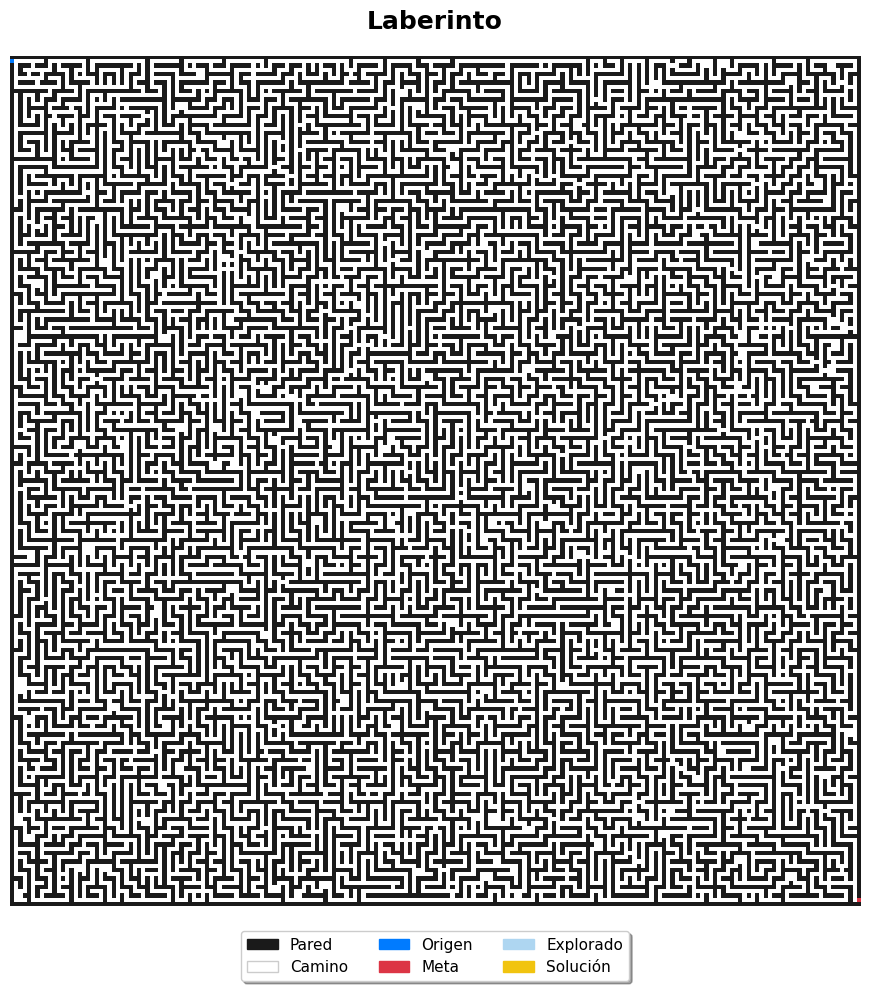

In [ ]:
print(f"Generando y dibujando laberinto de {ANCHO}x{ALTO}...")
laberinto = generar_laberinto(ANCHO, ALTO, probabilidad_romper_pared)

# Llamamos a la nueva función gráfica
dibujar_laberinto_grafico(laberinto)

# Transformar el algoritmo a un espacio de grafos

In [ ]:
"""
    Convierte la matriz del laberinto en un diccionario de adyacencia.
    Solo conecta celdas que sean CAMINO, ORIGEN o META.
"""
def construir_grafo(laberinto):

    filas = len(laberinto)
    columnas = len(laberinto[0])
    laberinto_grafos = {}

    # Definir qué valores son transitables
    transitables = {CAMINO, ORIGEN, META}

    for f in range(filas):
        for c in range(columnas):
            # Si la celda actual es transitable, la agregamos al grafo
            if laberinto[f][c] in transitables:
                nodo_actual = (f, c)
                laberinto_grafos[nodo_actual] = []

                # Revisar las 4 direcciones adyacentes (Arriba, Abajo, Izquierda, Derecha)
                for df, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nf, nc = f + df, c + dc

                    # Verificar que el vecino esté dentro de la matriz y sea transitable
                    if 0 <= nf < filas and 0 <= nc < columnas:
                        if laberinto[nf][nc] in transitables:
                            # Añadir el vecino a la lista de adyacencia
                            laberinto_grafos[nodo_actual].append((nf, nc))

    return laberinto_grafos

grafo = construir_grafo(laberinto)
print(f"Grafo generado con {len(grafo)} nodos transitables.")

Grafo generado con 20776 nodos transitables.


#Librerias y Copias de Laberintos

In [ ]:
import time
import copy

laberinto_dfs = copy.deepcopy(laberinto)
laberinto_bfs = copy.deepcopy(laberinto)
laberinto_dijkstra = copy.deepcopy(laberinto)
laberinto_astar = copy.deepcopy(laberinto)

#Funcion de reconstruccion

In [ ]:
def reconstruir_camino(padres, inicio, fin):
    camino = []
    actual = fin

    while actual is not None:
        camino.append(actual)
        actual = padres.get(actual)  # safer than padres[actual]

    camino.reverse()
    return camino

# DFS Implmentation

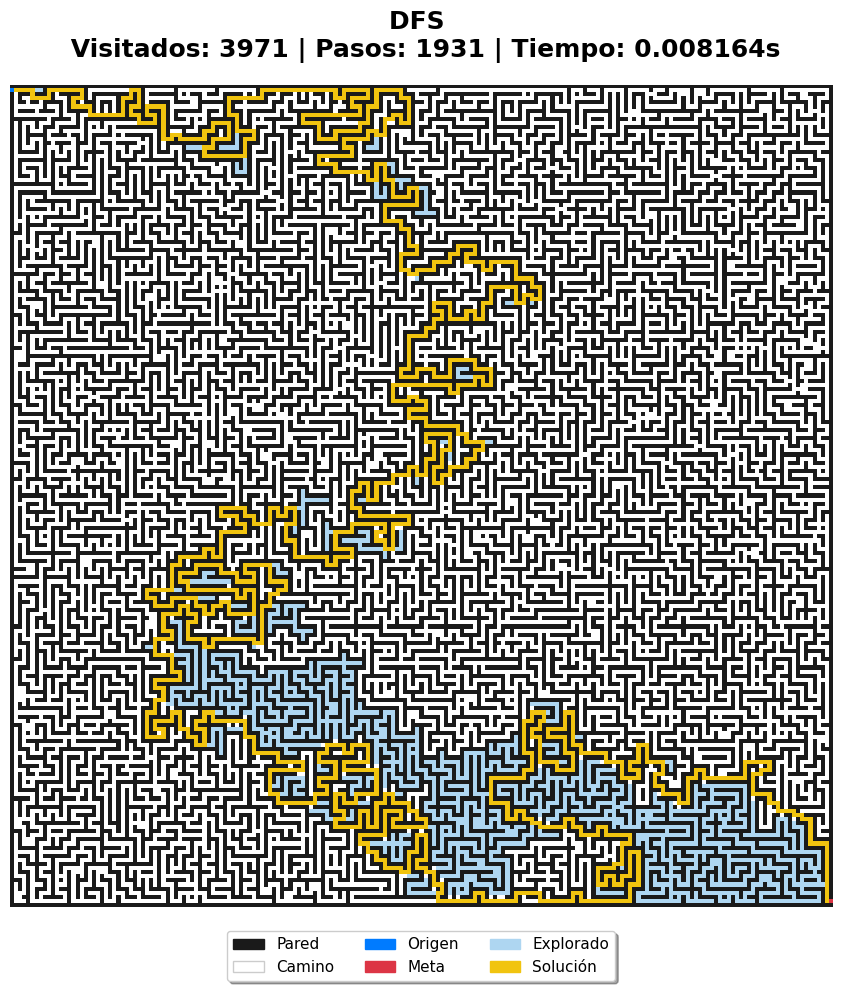

In [ ]:
def DFS(graph, start, end):
    visited = set()
    stack = [start]
    padres = {start: None}

    while stack:
        nodo = stack.pop()

        if nodo == end:
            return reconstruir_camino(padres, start, end), visited

        if nodo not in visited:
            visited.add(nodo)

            for neighbour in graph[nodo]:
                if neighbour not in padres:
                    padres[neighbour] = nodo
                    stack.append(neighbour)
    return None, visited


inicio = obtener_posicion(laberinto_dfs, ORIGEN)
fin = obtener_posicion(laberinto_dfs, META)

start_time = time.perf_counter()
camino, visitados = DFS(grafo, inicio, fin)
end_time = time.perf_counter()

for f, c in visitados:
  if laberinto_dfs[f][c] not in (ORIGEN, META):
    laberinto_dfs[f][c] = VISITADO

for f, c in camino:
  if laberinto_dfs[f][c] not in (ORIGEN, META):
    laberinto_dfs[f][c] = SOLUCION

num_visitados = len(visitados)
num_pasos = len(camino) if camino else 0
tiempo = end_time - start_time

titulo = f"DFS \n Visitados: {num_visitados} | Pasos: {num_pasos} | Tiempo: {tiempo:.6f}s"

dibujar_laberinto_grafico(laberinto_dfs, titulo)


#  BFS Implmentation

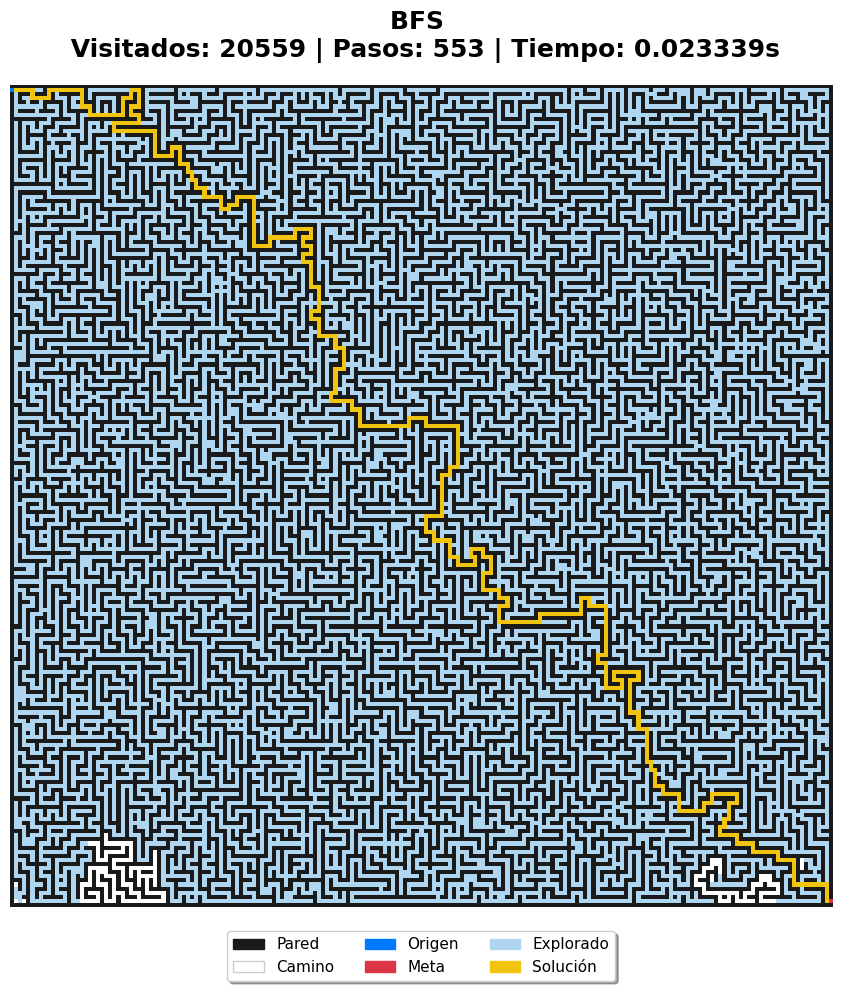

In [ ]:
def BFS(graph, start, end):
    visited = set()
    queue = [start]
    padres = {start: None}

    while queue:
        nodo = queue.pop(0)

        if nodo == end:
            return reconstruir_camino(padres, start, end), visited

        if nodo not in visited:
            visited.add(nodo)

            for neighbour in graph[nodo]:
                if neighbour not in padres:
                    padres[neighbour] = nodo
                    queue.append(neighbour)
    return None, visited

inicio = obtener_posicion(laberinto_bfs, ORIGEN)
fin = obtener_posicion(laberinto_bfs, META)

start_time = time.perf_counter()
camino, visitados = BFS(grafo, inicio, fin)
end_time = time.perf_counter()

for f, c in visitados:
  if laberinto_bfs[f][c] not in (ORIGEN, META):
    laberinto_bfs[f][c] = VISITADO

for f, c in camino:
  if laberinto_bfs[f][c] not in (ORIGEN, META):
    laberinto_bfs[f][c] = SOLUCION

num_visitados = len(visitados)
num_pasos = len(camino) if camino else 0
tiempo = end_time - start_time

titulo = f"BFS \n Visitados: {num_visitados} | Pasos: {num_pasos} | Tiempo: {tiempo:.6f}s"

dibujar_laberinto_grafico(laberinto_bfs, titulo)

#  Dijkstra Implmentation

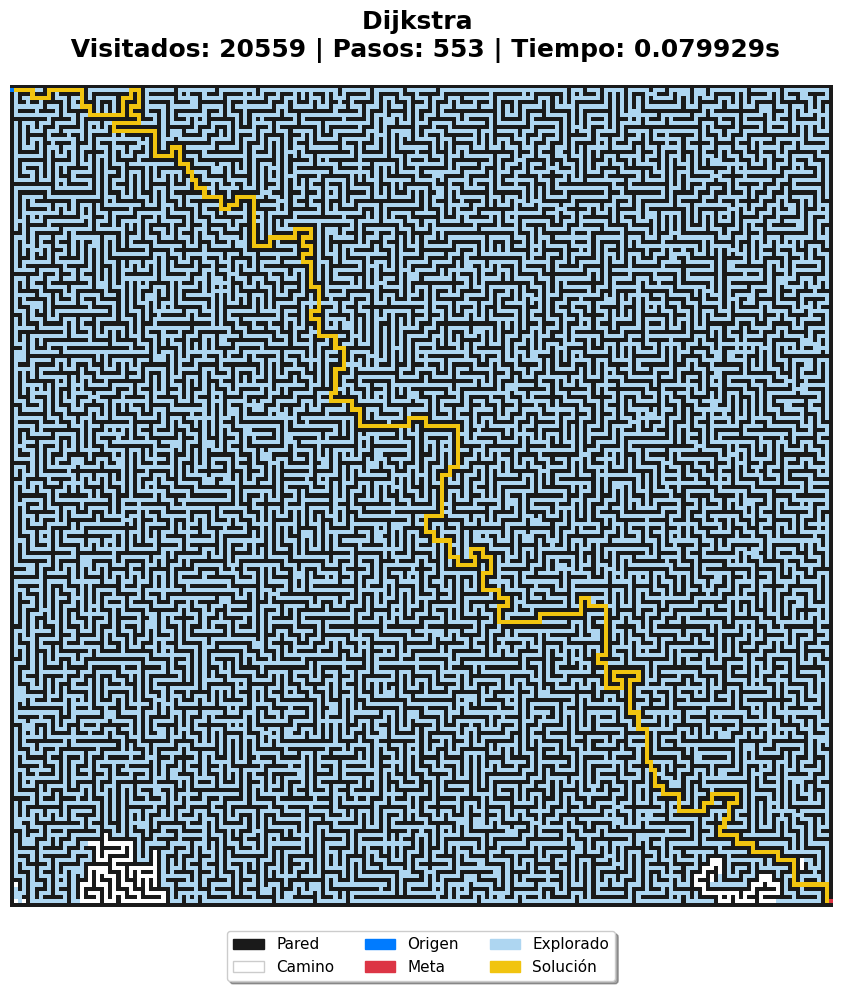

In [ ]:
def dijkstra(graph, start, end):
    visited = set()
    queue = [(0, start)]
    padres = {start: None}
    dist = {start: 0}

    while queue:
        queue.sort(key=lambda x: x[0])
        cost, nodo = queue.pop(0)

        if nodo == end:
            return reconstruir_camino(padres, start, end), visited

        if nodo not in visited:
            visited.add(nodo)

            for vecino in graph[nodo]:
                new_d = cost + 1

                if vecino not in dist:
                    dist[vecino] = new_d
                    padres[vecino] = nodo
                    queue.append((new_d, vecino))

                elif new_d < dist[vecino]:
                    dist[vecino] = new_d
                    padres[vecino] = nodo
                    queue.append((new_d, vecino))

    return None, visited


inicio = obtener_posicion(laberinto_dijkstra, ORIGEN)
fin = obtener_posicion(laberinto_dijkstra, META)

start_time = time.perf_counter()
camino, visitados = dijkstra(grafo, inicio, fin)
end_time = time.perf_counter()

for f, c in visitados:
  if laberinto_dijkstra[f][c] not in (ORIGEN, META):
    laberinto_dijkstra[f][c] = VISITADO

for f, c in camino:
  if laberinto_dijkstra[f][c] not in (ORIGEN, META):
    laberinto_dijkstra[f][c] = SOLUCION

num_visitados = len(visitados)
num_pasos = len(camino) if camino else 0
tiempo = end_time - start_time

titulo = f"Dijkstra \n Visitados: {num_visitados} | Pasos: {num_pasos} | Tiempo: {tiempo:.6f}s"

dibujar_laberinto_grafico(laberinto_dijkstra, titulo)

#  A* Implmentation

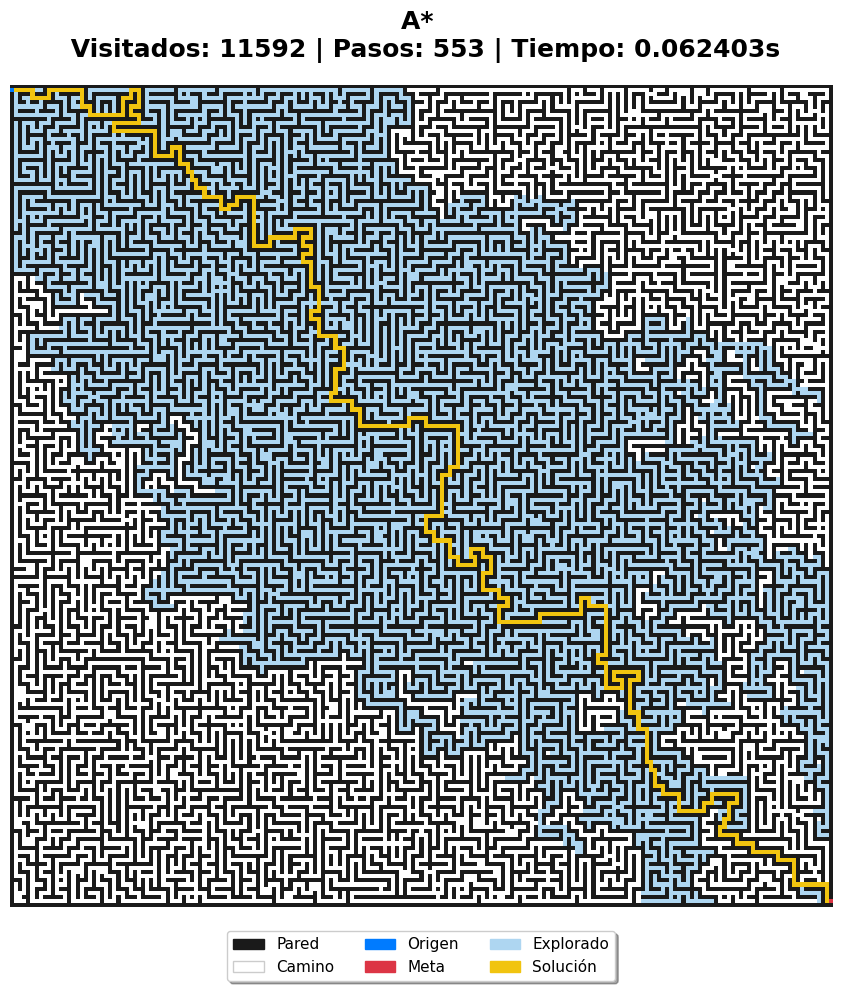

In [ ]:
def astar(graph, start, end):
    visited = set()
    queue = [(heuristic(start, end), start)]  # (f(n), node)
    dist = {start: 0}     # g(n)
    padres = {start: None}

    while queue:
        queue.sort(key=lambda x: x[0])
        f, nodo = queue.pop(0)

        if nodo == end:
            return reconstruir_camino(padres, start, end), visited

        if nodo not in visited:
            visited.add(nodo)

            for vecino in graph[nodo]:
                new_d = dist[nodo] + 1

                if vecino not in dist:
                    dist[vecino] = new_d
                    padres[vecino] = nodo
                    new_f = new_d + heuristic(vecino, end)
                    queue.append((new_f, vecino))

                elif new_d < dist[vecino]:
                    dist[vecino] = new_d
                    padres[vecino] = nodo
                    new_f = new_d + heuristic(vecino, end)
                    queue.append((new_f, vecino))

    return None, visited


def heuristic(p, end):
  x_p, y_p = p[0], p[1]
  x_e, y_e = end[0], end[1]
  return (abs(x_e - x_p) + abs(y_e - y_p))

inicio = obtener_posicion(laberinto_astar, ORIGEN)
fin = obtener_posicion(laberinto_astar, META)

start_time = time.perf_counter()
camino, visitados = astar(grafo, inicio, fin)
end_time = time.perf_counter()

for f, c in visitados:
  if laberinto_astar[f][c] not in (ORIGEN, META):
    laberinto_astar[f][c] = VISITADO

for f, c in camino:
  if laberinto_astar[f][c] not in (ORIGEN, META):
    laberinto_astar[f][c] = SOLUCION

num_visitados = len(visitados)
num_pasos = len(camino) if camino else 0
tiempo = end_time - start_time

titulo = f"A* \n Visitados: {num_visitados} | Pasos: {num_pasos} | Tiempo: {tiempo:.6f}s"

dibujar_laberinto_grafico(laberinto_astar, titulo)